# Feature Selection: SelectKBest + ANOVA (f_classif) - Combined

This notebook is a **first-pass feature selection baseline** for emotion classification.

What it does:
- loads one feature CSV
- separates metadata from model features
- trains a baseline model
- applies `SelectKBest(f_classif)`
- retrains and compares performance
- visualizes top ANOVA feature scores
- saves selected feature names and transformed datasets

**Default dataset key for this notebook:** `bert`


## 1) Imports and Notebook Settings

This cell sets up dependencies and plotting style.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
from tqdm.auto import tqdm

plt.style.use('ggplot')
np.random.seed(42)

print('Imports loaded.')


Imports loaded.


## 2) Configuration

Pick which extracted feature table to run.

Recommended first run: `mfcc_raw` (fast and stable).

In [3]:
REPO_ROOT = Path.cwd().resolve().parents[2] if 'feature_selection' in str(Path.cwd()) else Path.cwd().resolve()

FEATURE_SOURCES = {
    'mfcc_raw': REPO_ROOT / 'extracted_features' / 'mfcc' / 'mfcc_features.csv',
    'mfcc_normalized': REPO_ROOT / 'extracted_features' / 'mfcc' / 'mfcc_features_normalized.csv',
    'prosody_energy': REPO_ROOT / 'extracted_features' / 'prosody_energy' / 'prosody_energy_features.csv',
    'prosody_pitch': REPO_ROOT / 'extracted_features' / 'prosody_pitch' / 'prosody_pitch_features.csv',
    'bert': REPO_ROOT / 'extracted_features' / 'text' / 'bert_embeddings.csv',
    'tfidf': REPO_ROOT / 'extracted_features' / 'text' / 'tfidf_features.csv',
    'representations': REPO_ROOT / 'extracted_features' / 'representations' / 'representations_features.csv',
    'rhythm_pauses': REPO_ROOT / 'extracted_features' / 'rhythm_pauses' / 'rhythm_pauses_features.csv',
    'tonality': REPO_ROOT / 'extracted_features' / 'tonality' / 'tonality_features.csv',
    'ssl_hubert': REPO_ROOT / 'extracted_features' / 'ssl_embeddings' / 'ssl_embeddings_hubert_features.csv',
    'ssl_wav2vec': REPO_ROOT / 'extracted_features' / 'ssl_embeddings' / 'ssl_embeddings_wav2vec_features.csv',
    'combined': REPO_ROOT / 'extracted_features' / 'combined' / 'all_families_features.csv'
}


DATASET_KEY = 'combined'   # change as needed
TARGET_COL = 'emotion'
TEST_SIZE = 0.20
RANDOM_STATE = 42
K_FEATURES = 300       # can be int or 'all'; actual k is clipped to available features
USE_NROWS = None           # set e.g. 5000 for quick smoke runs on huge CSVs

METADATA_CANDIDATES = {
    'path', 'session', 'method', 'gender', 'emotion', 'n_annotators', 'agreement',
    'utt_id', 'text', 'split'
}

source_path = FEATURE_SOURCES[DATASET_KEY]
print(f'Repository root: {REPO_ROOT}')
print(f'Selected source: {source_path}')
print('Source exists:', source_path.exists())


Repository root: F:\Speech-Emotion-Recognition
Selected source: F:\Speech-Emotion-Recognition\extracted_features\combined\all_families_features.csv
Source exists: True


## 3) Load Data and Identify Feature Columns

This cell infers feature columns by excluding known metadata columns.

C:\Users\Bex\AppData\Local\Temp\ipykernel_13276\3246213990.py:4: DtypeWarning: Columns (2329,2330,2331) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(source_path, nrows=USE_NROWS)


Data shape: (9887, 15359)
Metadata columns (13): ['session', 'method', 'gender', 'emotion', 'n_annotators', 'agreement', 'path', 'tfidf__utt_id', 'tfidf__text', 'tfidf__split', 'bert__utt_id', 'bert__text', 'bert__split']
Feature columns (15346).
Sample feature columns: ['mfcc_raw__duration_s', 'mfcc_raw__mfcc13_mfcc_frames', 'mfcc_raw__mfcc13_mfcc_mean', 'mfcc_raw__mfcc13_mfcc_std', 'mfcc_raw__mfcc13_mfcc_min', 'mfcc_raw__mfcc13_mfcc_max', 'mfcc_raw__mfcc13_mfcc_median', 'mfcc_raw__mfcc13_mfcc_c00_mean', 'mfcc_raw__mfcc13_mfcc_c00_std', 'mfcc_raw__mfcc13_mfcc_c00_min']
Class distribution:
emotion
xxx    2507
fru    1849
neu    1708
ang    1103
sad    1084
exc    1041
hap     595
Name: count, dtype: int64


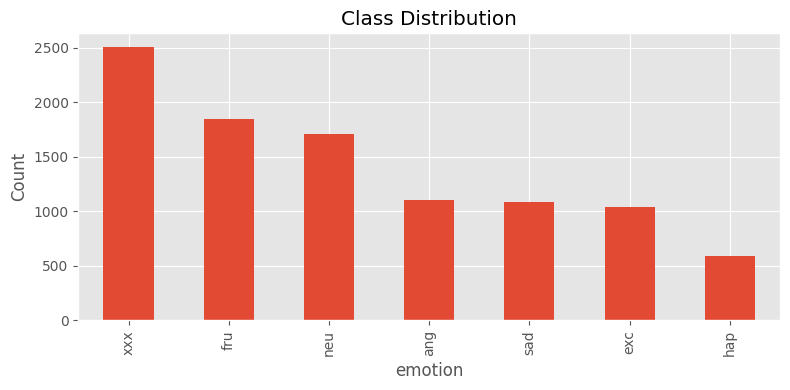

In [4]:
if not source_path.exists():
    raise FileNotFoundError(f'Missing source CSV: {source_path}')

df = pd.read_csv(source_path, nrows=USE_NROWS)

if TARGET_COL not in df.columns:
    raise ValueError(f"Target column '{TARGET_COL}' not found. Available: {list(df.columns[:20])}...")

# Match the same cleaning style as other notebooks, while handling prefixed metadata
# present in combined tables (e.g. family__utt_id, family__text).
def is_metadata_column(col: str) -> bool:
    if col in METADATA_CANDIDATES:
        return True
    if '__' in col:
        suffix = col.rsplit('__', 1)[-1]
        return suffix in METADATA_CANDIDATES
    return False

meta_cols = [c for c in df.columns if is_metadata_column(c)]
feature_cols = [c for c in df.columns if not is_metadata_column(c)]

print(f'Data shape: {df.shape}')
print(f'Metadata columns ({len(meta_cols)}): {meta_cols[:20]}{" ..." if len(meta_cols) > 20 else ""}')
print(f'Feature columns ({len(feature_cols)}).')
print('Sample feature columns:', feature_cols[:10])

# quick class balance view
class_counts = df[TARGET_COL].value_counts(dropna=False)
print('Class distribution:')
print(class_counts)

fig, ax = plt.subplots(figsize=(8, 4))
class_counts.plot(kind='bar', ax=ax)
ax.set_title('Class Distribution')
ax.set_xlabel(TARGET_COL)
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


## 4) Basic Cleaning and Train/Test Split

Rows with missing labels or missing feature values are removed.

In [5]:
model_df = df[[TARGET_COL] + feature_cols].copy()

rows_before = len(model_df)
# 1) keep only rows with labels
model_df = model_df.dropna(subset=[TARGET_COL])
model_df = model_df.dropna(axis=1, how='any')
feature_cols = [c for c in feature_cols if c in model_df.columns]
rows_after = len(model_df)

X = model_df[feature_cols].astype(float)
y_raw = model_df[TARGET_COL].astype(str)

label_enc = LabelEncoder()
y = label_enc.fit_transform(y_raw)

split_kwargs = dict(
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)
if len(np.unique(y)) > 1 and y_raw.value_counts().min() >= 2:
    split_kwargs['stratify'] = y
else:
    print('Warning: stratified split disabled due to insufficient per-class samples.')
    split_kwargs['stratify'] = None

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    **split_kwargs,
)

print(f'Rows before cleaning: {rows_before}')
print(f'Rows after cleaning:  {rows_after}')
print(f'Dropped rows:         {rows_before - rows_after}')
print(f'Train shape: {X_train.shape}')
print(f'Test shape:  {X_test.shape}')
print(f'Classes: {list(label_enc.classes_)}')


Rows before cleaning: 9887
Rows after cleaning:  9887
Dropped rows:         0
Train shape: (7909, 4859)
Test shape:  (1978, 4859)
Classes: ['ang', 'exc', 'fru', 'hap', 'neu', 'sad', 'xxx']


## 5) Baseline Model (No Feature Selection)

A logistic regression baseline gives a reference before selection.

Training (baseline):   0%|          | 0/1 [00:00<?, ?model/s]

Baseline metrics (all models):
   stage         model  accuracy  precision  recall     f1
baseline random_forest    0.4287     0.4743  0.4287 0.4134

[random_forest] classification report (baseline):
              precision    recall  f1-score   support

         ang       0.52      0.48      0.50       221
         exc       0.50      0.24      0.32       208
         fru       0.46      0.39      0.42       370
         hap       0.67      0.02      0.03       119
         neu       0.54      0.32      0.40       342
         sad       0.58      0.63      0.60       217
         xxx       0.33      0.59      0.42       501

    accuracy                           0.43      1978
   macro avg       0.51      0.38      0.39      1978
weighted avg       0.47      0.43      0.41      1978



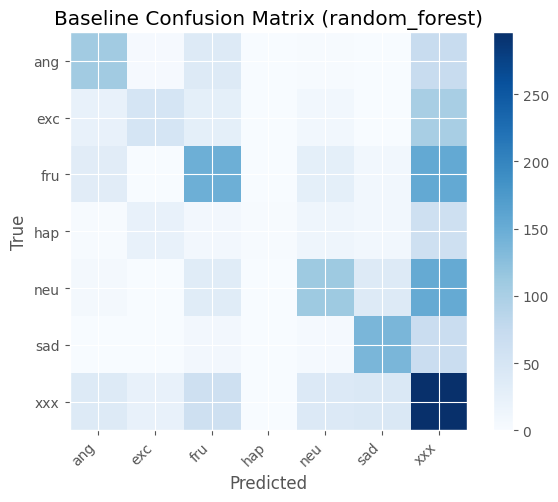

In [6]:
MODEL_SPECS = {
    # 'logreg': Pipeline([
    #     ('scaler', StandardScaler()),
    #     ('clf', LogisticRegression(max_iter=4000, class_weight='balanced', random_state=RANDOM_STATE)),
    # ]),
    # 'linear_svc': Pipeline([
    #     ('scaler', StandardScaler()),
    #     ('clf', LinearSVC(class_weight='balanced', random_state=RANDOM_STATE, max_iter=8000)),
    # ]),
    'random_forest': Pipeline([
        ('scaler', 'passthrough'),
        ('clf', RandomForestClassifier(
            n_estimators=500,
            class_weight='balanced_subsample',
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]),
}

all_labels = np.arange(len(label_enc.classes_))

def evaluate_models(X_train_eval, y_train_eval, X_test_eval, y_test_eval, stage_name: str):
    rows = []
    preds = {}

    model_iter = tqdm(
        MODEL_SPECS.items(),
        total=len(MODEL_SPECS),
        desc=f'Training ({stage_name})',
        unit='model',
        leave=False,
    )
    for model_name, estimator in model_iter:
        model = clone(estimator)
        model.fit(X_train_eval, y_train_eval)
        y_pred = model.predict(X_test_eval)

        preds[model_name] = y_pred
        rows.append({
            'stage': stage_name,
            'model': model_name,
            'accuracy': accuracy_score(y_test_eval, y_pred),
            'precision': precision_score(y_test_eval, y_pred, average='weighted', zero_division=0),
            'recall': recall_score(y_test_eval, y_pred, average='weighted', zero_division=0),
            'f1': f1_score(y_test_eval, y_pred, average='weighted'),
                    })

    metrics_df = pd.DataFrame(rows).sort_values('f1', ascending=False, ignore_index=True)
    return metrics_df, preds


def plot_confusion(y_true, y_pred, title: str):
    cm = confusion_matrix(y_true, y_pred, labels=all_labels)
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap='Blues')
    fig.colorbar(im, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_xticks(range(len(label_enc.classes_)))
    ax.set_yticks(range(len(label_enc.classes_)))
    ax.set_xticklabels(label_enc.classes_, rotation=45, ha='right')
    ax.set_yticklabels(label_enc.classes_)
    plt.tight_layout()
    plt.show()


baseline_results, baseline_preds = evaluate_models(X_train, y_train, X_test, y_test, stage_name='baseline')

print('Baseline metrics (all models):')
print(baseline_results.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

for model_name in baseline_results['model']:
    print(f'\n[{model_name}] classification report (baseline):')
    print(classification_report(
        y_test,
        baseline_preds[model_name],
        labels=all_labels,
        target_names=label_enc.classes_,
        zero_division=0,
    ))

best_baseline_model = baseline_results.loc[0, 'model']
plot_confusion(y_test, baseline_preds[best_baseline_model], f'Baseline Confusion Matrix ({best_baseline_model})')

base_acc = float(baseline_results.loc[0, 'accuracy'])
base_f1 = float(baseline_results.loc[0, 'f1'])


## 6) SelectKBest (ANOVA F-test)

`f_classif` ranks each feature independently by class separability.

Original feature count: 4859
Selected feature count: 300
First 15 selected features:
 - mfcc_raw__mfcc13_mfcc_std
 - mfcc_raw__mfcc13_mfcc_c00_mean
 - mfcc_raw__mfcc13_mfcc_c00_std
 - mfcc_raw__mfcc13_mfcc_c00_max
 - mfcc_raw__mfcc13_mfcc_c00_median
 - mfcc_raw__mfcc13_mfcc_c01_mean
 - mfcc_raw__mfcc13_mfcc_c01_median
 - mfcc_raw__mfcc13_mfcc_c02_std
 - mfcc_raw__mfcc13_mfcc_c03_std
 - mfcc_raw__mfcc13_mfcc_c03_min
 - mfcc_raw__mfcc13_mfcc_c04_std
 - mfcc_raw__mfcc13_mfcc_c05_std
 - mfcc_raw__mfcc13_mfcc_c06_std
 - mfcc_raw__mfcc13_mfcc_c08_std
 - mfcc_raw__mfcc13_mfcc_c09_std
Top 10 ANOVA-ranked features:
                              feature  anova_f_score
0      mfcc_normalized__mfcc40_d1_std     552.797370
1             mfcc_raw__mfcc40_d1_std     552.797369
2      mfcc_normalized__mfcc20_d1_std     518.824294
3             mfcc_raw__mfcc20_d1_std     518.824293
4             mfcc_raw__mfcc13_d1_std     493.235188
5      mfcc_normalized__mfcc13_d1_std     493.235185
6  mfcc_normali

f:\Speech-Emotion-Recognition\.venv\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [2306 3089 3093 3231] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
f:\Speech-Emotion-Recognition\.venv\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


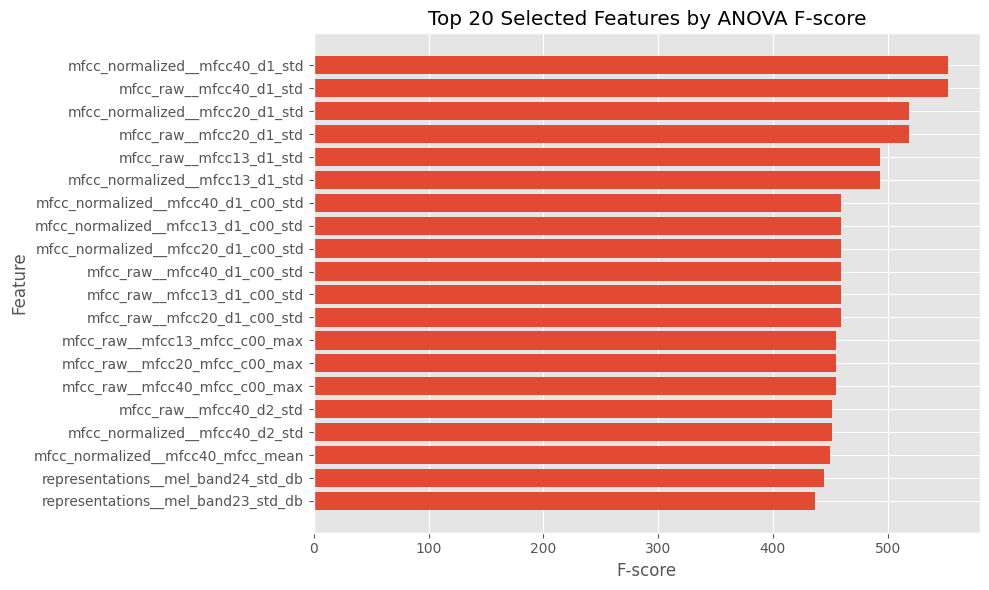

In [7]:
if K_FEATURES == 'all':
    k = 'all'
else:
    k = min(int(K_FEATURES), X_train.shape[1])

selector = SelectKBest(score_func=f_classif, k=k)
selector.fit(X_train, y_train)

mask = selector.get_support()
selected_features = [col for col, keep in zip(feature_cols, mask) if keep]
selected_scores = selector.scores_[mask]

print(f'Original feature count: {X_train.shape[1]}')
print(f'Selected feature count: {len(selected_features)}')
print('First 15 selected features:')
for name in selected_features[:15]:
    print(' -', name)

# Top ANOVA scores
rank_df = pd.DataFrame({
    'feature': selected_features,
    'anova_f_score': selected_scores,
}).sort_values('anova_f_score', ascending=False, ignore_index=True)

print('Top 10 ANOVA-ranked features:')
print(rank_df.head(10))

plot_n = min(20, len(rank_df))
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(rank_df.head(plot_n)['feature'][::-1], rank_df.head(plot_n)['anova_f_score'][::-1])
ax.set_title(f'Top {plot_n} Selected Features by ANOVA F-score')
ax.set_xlabel('F-score')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

## 7) Model After Selection

Train the same classifier, now only on selected features.

Training (selected):   0%|          | 0/1 [00:00<?, ?model/s]

Post-selection metrics (all models):
   stage         model  accuracy  precision  recall     f1
selected random_forest    0.3787     0.3990  0.3787 0.3676

[random_forest] classification report (post-selection):
              precision    recall  f1-score   support

         ang       0.48      0.44      0.46       221
         exc       0.37      0.23      0.28       208
         fru       0.39      0.35      0.37       370
         hap       0.57      0.03      0.06       119
         neu       0.38      0.34      0.36       342
         sad       0.51      0.55      0.53       217
         xxx       0.31      0.47      0.37       501

    accuracy                           0.38      1978
   macro avg       0.43      0.34      0.35      1978
weighted avg       0.40      0.38      0.37      1978



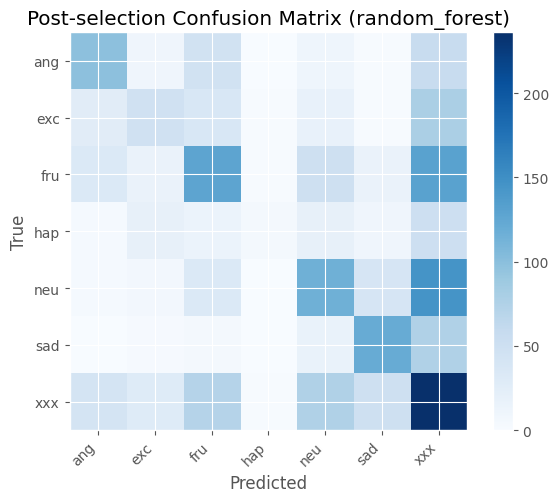


Metric delta by model (selected - baseline):
        model  accuracy_baseline  precision_baseline  recall_baseline  f1_baseline  accuracy_selected  precision_selected  recall_selected  f1_selected  accuracy_delta  precision_delta  recall_delta  f1_delta
random_forest             0.4287              0.4743           0.4287       0.4134             0.3787              0.3990           0.3787       0.3676         -0.0501          -0.0753       -0.0501   -0.0458


In [8]:
X_train_sel = selector.transform(X_train)
X_test_sel = selector.transform(X_test)

selected_results, selected_preds = evaluate_models(
    X_train_sel,
    y_train,
    X_test_sel,
    y_test,
    stage_name='selected',
)

print('Post-selection metrics (all models):')
print(selected_results.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

for model_name in selected_results['model']:
    print(f'\n[{model_name}] classification report (post-selection):')
    print(classification_report(
        y_test,
        selected_preds[model_name],
        labels=all_labels,
        target_names=label_enc.classes_,
        zero_division=0,
    ))

best_selected_model = selected_results.loc[0, 'model']
plot_confusion(y_test, selected_preds[best_selected_model], f'Post-selection Confusion Matrix ({best_selected_model})')

comparison_df = baseline_results[['model', 'accuracy', 'precision', 'recall', 'f1']].merge(
    selected_results[['model', 'accuracy', 'precision', 'recall', 'f1']],
    on='model',
    suffixes=('_baseline', '_selected'),
)
comparison_df['accuracy_delta'] = comparison_df['accuracy_selected'] - comparison_df['accuracy_baseline']
comparison_df['precision_delta'] = comparison_df['precision_selected'] - comparison_df['precision_baseline']
comparison_df['recall_delta'] = comparison_df['recall_selected'] - comparison_df['recall_baseline']
comparison_df['f1_delta'] = comparison_df['f1_selected'] - comparison_df['f1_baseline']
comparison_df = comparison_df.sort_values('f1_selected', ascending=False, ignore_index=True)

print('\nMetric delta by model (selected - baseline):')
print(comparison_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

sel_acc = float(selected_results.loc[0, 'accuracy'])
sel_f1 = float(selected_results.loc[0, 'f1'])


## 8) Save Artifacts

This exports selected feature names, scores, and transformed train/test matrices.

In [9]:
out_dir = REPO_ROOT / 'feature_selection' / 'anova' / 'select_k_best_anova' / 'artifacts'
out_dir.mkdir(parents=True, exist_ok=True)

selected_feature_path = out_dir / f'{DATASET_KEY}_selected_features.json'
rank_path = out_dir / f'{DATASET_KEY}_anova_ranking.csv'
train_sel_path = out_dir / f'{DATASET_KEY}_X_train_selected.csv'
test_sel_path = out_dir / f'{DATASET_KEY}_X_test_selected.csv'
meta_path = out_dir / f'{DATASET_KEY}_run_metadata.json'

with selected_feature_path.open('w', encoding='utf-8') as f:
    json.dump(selected_features, f, indent=2)

rank_df.to_csv(rank_path, index=False)

X_train_sel_df = pd.DataFrame(X_train_sel, columns=selected_features)
X_test_sel_df = pd.DataFrame(X_test_sel, columns=selected_features)
X_train_sel_df.to_csv(train_sel_path, index=False)
X_test_sel_df.to_csv(test_sel_path, index=False)

baseline_records = baseline_results.to_dict(orient='records')
selected_records = selected_results.to_dict(orient='records')
comparison_records = comparison_df.to_dict(orient='records')
for collection in (baseline_records, selected_records, comparison_records):
    for row in collection:
        for key, value in list(row.items()):
            if isinstance(value, (np.floating, float)):
                row[key] = float(value)

run_meta = {
    'dataset_key': DATASET_KEY,
    'source_path': str(source_path),
    'target_col': TARGET_COL,
    'rows_used': int(len(model_df)),
    'original_features': int(X_train.shape[1]),
    'selected_features': int(len(selected_features)),
    'k_config': K_FEATURES,
    'k_effective': len(selected_features),
    'random_state': RANDOM_STATE,
    'test_size': TEST_SIZE,
    'best_baseline_model': str(baseline_results.loc[0, 'model']),
    'best_selected_model': str(selected_results.loc[0, 'model']),
    'baseline_accuracy': float(base_acc),
    'baseline_precision': float(baseline_results.loc[0, 'precision']),
    'baseline_recall': float(baseline_results.loc[0, 'recall']),
    'baseline_f1': float(base_f1),
    'selected_accuracy': float(sel_acc),
    'selected_precision': float(selected_results.loc[0, 'precision']),
    'selected_recall': float(selected_results.loc[0, 'recall']),
    'selected_f1': float(sel_f1),
    'baseline_model_metrics': baseline_records,
    'selected_model_metrics': selected_records,
    'model_metric_deltas': comparison_records,
}

with meta_path.open('w', encoding='utf-8') as f:
    json.dump(run_meta, f, indent=2)

print('Saved artifacts:')
print('-', selected_feature_path)
print('-', rank_path)
print('-', train_sel_path)
print('-', test_sel_path)
print('-', meta_path)


Saved artifacts:
- F:\Speech-Emotion-Recognition\feature_selection\anova\select_k_best_anova\artifacts\combined_selected_features.json
- F:\Speech-Emotion-Recognition\feature_selection\anova\select_k_best_anova\artifacts\combined_anova_ranking.csv
- F:\Speech-Emotion-Recognition\feature_selection\anova\select_k_best_anova\artifacts\combined_X_train_selected.csv
- F:\Speech-Emotion-Recognition\feature_selection\anova\select_k_best_anova\artifacts\combined_X_test_selected.csv
- F:\Speech-Emotion-Recognition\feature_selection\anova\select_k_best_anova\artifacts\combined_run_metadata.json


## 9) Notes for Next Methods

After this baseline, common next folders/methods:
- `wrapper/rfe_logreg/`
- `embedded/l1_logreg/`
- `embedded/tree_importance/`
- `dimensionality/pca/`

In [10]:
# Delta summary (selected - baseline)
if 'comparison_df' not in globals():
    raise RuntimeError('comparison_df not found. Run the training/evaluation cells first.')

delta_cols = [
    'model',
    'accuracy_baseline',
    'accuracy_selected',
    'accuracy_delta',
    'precision_baseline',
    'precision_selected',
    'precision_delta',
    'recall_baseline',
    'recall_selected',
    'recall_delta',
    'f1_baseline',
    'f1_selected',
    'f1_delta',
]

delta_table = comparison_df[delta_cols].copy().sort_values('f1_delta', ascending=False, ignore_index=True)

print('Delta table (selected - baseline):')
print(delta_table.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

print('\nDelta accuracy only:')
print(
    delta_table[['model', 'accuracy_baseline', 'accuracy_selected', 'accuracy_delta']]
    .to_string(index=False, float_format=lambda x: f'{x:.4f}')
)

print('\nDelta precision only:')
print(
    delta_table[['model', 'precision_baseline', 'precision_selected', 'precision_delta']]
    .to_string(index=False, float_format=lambda x: f'{x:.4f}')
)

print('\nDelta recall only:')
print(
    delta_table[['model', 'recall_baseline', 'recall_selected', 'recall_delta']]
    .to_string(index=False, float_format=lambda x: f'{x:.4f}')
)

print('\nDelta F1 only:')
print(
    delta_table[['model', 'f1_baseline', 'f1_selected', 'f1_delta']]
    .to_string(index=False, float_format=lambda x: f'{x:.4f}')
)

best_gain_row = delta_table.iloc[0]
print(
    f"\nBest F1 gain: {best_gain_row['model']} | "
    f"Delta F1={best_gain_row['f1_delta']:+.4f}, "
    f"Delta Accuracy={best_gain_row['accuracy_delta']:+.4f}"
)


Delta table (selected - baseline):
        model  accuracy_baseline  accuracy_selected  accuracy_delta  precision_baseline  precision_selected  precision_delta  recall_baseline  recall_selected  recall_delta  f1_baseline  f1_selected  f1_delta
random_forest             0.4287             0.3787         -0.0501              0.4743              0.3990          -0.0753           0.4287           0.3787       -0.0501       0.4134       0.3676   -0.0458

Delta accuracy only:
        model  accuracy_baseline  accuracy_selected  accuracy_delta
random_forest             0.4287             0.3787         -0.0501

Delta precision only:
        model  precision_baseline  precision_selected  precision_delta
random_forest              0.4743              0.3990          -0.0753

Delta recall only:
        model  recall_baseline  recall_selected  recall_delta
random_forest           0.4287           0.3787       -0.0501

Delta F1 only:
        model  f1_baseline  f1_selected  f1_delta
random_forest 